# DBSCAN-Based Detection of Environmental Anomalies in Ahmedabad (2023–2025)

This project applies the DBSCAN clustering algorithm to identify unusual air pollution events (anomalies) using CPCB monitoring data from multiple stations in Ahmedabad.


## Objective

The main goal of this project is to detect abnormal pollution spikes using an unsupervised machine learning approach.

We aim to:
- Cluster normal air quality patterns
- Identify rare pollution events as anomalies
- Analyze seasonal and station-wise anomaly trends

## Dataset Description

Source: CPCB CAAQMS Air Quality Monitoring Data  
Location: Ahmedabad, Gujarat  
Duration: 2023–2025  
Stations: 9 monitoring sites

Pollutants included:
- PM2.5, PM10, NO₂, SO₂, CO, O₃

# Loading the dataset

In [1]:
import pandas as pd
df=pd.read_csv("pollution_data.csv")
df

,Station_ID,Station_Name,City,Date,PM2.5 (µg/m³),PM10 (µg/m³),NO₂ (µg/m³),SO₂ (µg/m³),CO (mg/m³),O₃ (µg/m³)
0,AHM01,Chandkheda,Ahmedabad,01-01-2023,NaN,NaN,NaN,NaN,NaN,NaN
1,AHM01,Chandkheda,Ahmedabad,02-01-2023,NaN,NaN,NaN,NaN,NaN,NaN
2,AHM01,Chandkheda,Ahmedabad,03-01-2023,NaN,NaN,NaN,NaN,NaN,NaN
3,AHM01,Chandkheda,Ahmedabad,04-01-2023,NaN,NaN,NaN,NaN,NaN,NaN
4,AHM01,Chandkheda,Ahmedabad,05-01-2023,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
9859,AHM09,Sardar Vallabhai Patel Stadium,Ahmedabad,27-12-2025,NaN,NaN,NaN,NaN,NaN,NaN
9860,AHM09,Sardar Vallabhai Patel Stadium,Ahmedabad,28-12-2025,NaN,NaN,NaN,NaN,NaN,NaN
9861,AHM09,Sardar Vallabhai Patel Stadium,Ahmedabad,29-12-2025,NaN,NaN,NaN,NaN,NaN,NaN
9862,AHM09,Sardar Vallabhai Patel Stadium,Ahmedabad,30-12-2025,NaN,NaN,NaN,NaN,NaN,NaN


In [2]:
df.shape

(9864, 10)

In [3]:
# Data informtion
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9864 entries, 0 to 9863
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Station_ID     9864 non-null   str    
 1   Station_Name   9864 non-null   str    
 2   City           9864 non-null   str    
 3   Date           9864 non-null   str    
 4   PM2.5 (µg/m³)  8641 non-null   float64
 5   PM10 (µg/m³)   8641 non-null   float64
 6   NO₂ (µg/m³)    8442 non-null   float64
 7   SO₂ (µg/m³)    8696 non-null   float64
 8   CO (mg/m³)     8562 non-null   float64
 9   O₃ (µg/m³)     8425 non-null   float64
dtypes: float64(6), str(4)
memory usage: 1.1 MB


In [4]:
df.describe()

,PM2.5 (µg/m³),PM10 (µg/m³),NO₂ (µg/m³),SO₂ (µg/m³),CO (mg/m³),O₃ (µg/m³)
count,8641.000000,8641.000000,8442.000000,8696.000000,8562.000000,8425.000000
mean,50.763105,105.154271,26.651984,12.485745,0.758037,25.214818
std,26.900137,49.757843,24.188973,13.396402,0.485815,16.840972
min,0.580000,3.370000,0.010000,0.050000,0.000000,1.190000
25%,30.780000,69.270000,11.480000,4.570000,0.470000,13.240000
50%,47.780000,99.630000,20.090000,8.620000,0.640000,21.240000
75%,65.710000,133.380000,33.977500,15.300000,0.940000,32.560000
max,269.610000,453.480000,331.500000,168.820000,6.060000,133.170000


In [5]:
#Checking for Nans in the whole data
print(df.isna().sum())

Station_ID          0
Station_Name        0
City                0
Date                0
PM2.5 (µg/m³)    1223
PM10 (µg/m³)     1223
NO₂ (µg/m³)      1422
SO₂ (µg/m³)      1168
CO (mg/m³)       1302
O₃ (µg/m³)       1439
dtype: int64


## Data Preprocessing

In [6]:
col=['PM2.5 (µg/m³)', 'PM10 (µg/m³)', 'NO₂ (µg/m³)', 'SO₂ (µg/m³)',	'CO (mg/m³)', 'O₃ (µg/m³)']
df[col].isna().all(axis=1).sum()

np.int64(901)

In [7]:
#Removing rows where all pollutant values are missing
df1=df.dropna(subset=col,how="all")

In [8]:
print(df1.isna().sum())

Station_ID         0
Station_Name       0
City               0
Date               0
PM2.5 (µg/m³)    322
PM10 (µg/m³)     322
NO₂ (µg/m³)      521
SO₂ (µg/m³)      267
CO (mg/m³)       401
O₃ (µg/m³)       538
dtype: int64


In [9]:
df1[col].dtypes

PM2.5 (µg/m³)    float64
PM10 (µg/m³)     float64
NO₂ (µg/m³)      float64
SO₂ (µg/m³)      float64
CO (mg/m³)       float64
O₃ (µg/m³)       float64
dtype: object

In [10]:
df1 = df1.copy()
# Converting Date column to datetime format 
df1['Date'] = pd.to_datetime(df1['Date'])

df1 = df1.sort_values(['Station_ID', 'Date'])
df1 = df1.set_index('Date')

# Time interpolation for short gaps
df1[col] = (df1.groupby('Station_ID')[col].transform(lambda x: x.interpolate(method='time', limit=3)))

# Applying forward/backward fill for long gaps 
df1[col] = df1.groupby('Station_ID')[col].ffill().bfill()

C:\Users\kanch\AppData\Local\Temp\ipykernel_8228\3980311756.py:3: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df1['Date'] = pd.to_datetime(df1['Date'])


In [11]:
df1[col].isna().sum()

PM2.5 (µg/m³)    0
PM10 (µg/m³)     0
NO₂ (µg/m³)      0
SO₂ (µg/m³)      0
CO (mg/m³)       0
O₃ (µg/m³)       0
dtype: int64

In [12]:
df1=df1.drop(columns=['Station_ID','City']) #both of these are not contributing anything to the output

In [13]:
df1

,Station_Name,PM2.5 (µg/m³),PM10 (µg/m³),NO₂ (µg/m³),SO₂ (µg/m³),CO (mg/m³),O₃ (µg/m³)
Date,,,,,,,
2023-01-13,Chandkheda,68.43,114.36,6.47,6.30,0.59,21.67
2023-01-14,Chandkheda,58.08,102.45,6.84,6.10,0.69,21.28
2023-01-15,Chandkheda,52.41,93.06,6.93,4.98,0.66,21.53
2023-01-16,Chandkheda,70.02,117.51,8.15,5.89,0.98,20.74
2023-01-17,Chandkheda,61.45,104.97,8.51,6.61,0.90,20.42
...,...,...,...,...,...,...,...
2025-08-25,Sardar Vallabhai Patel Stadium,9.36,34.37,23.66,10.42,0.46,9.53
2025-08-26,Sardar Vallabhai Patel Stadium,15.41,52.38,27.04,10.74,0.81,13.18
2025-08-27,Sardar Vallabhai Patel Stadium,19.20,59.70,23.98,13.69,0.78,14.86


# Feature Scaling

DBSCAN is distance-based, so pollutant features should be scaled which ensures all pollutants contribute equally to clustering.

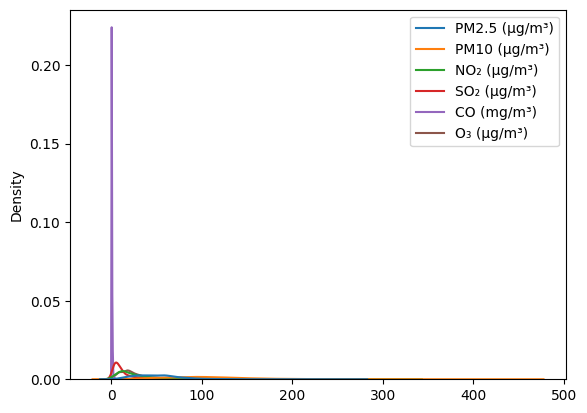

In [14]:
# Without scaling, the pollutants' contribution is very different and misleading
import seaborn as sns
sns.kdeplot(df1[col]);

In [15]:
# RobustScaler is used to normalize air pollution features
from sklearn.preprocessing import RobustScaler
x=df1[col]
sc=RobustScaler()
x_scaled=sc.fit_transform(x)
x_scaled = pd.DataFrame(x_scaled,columns=col,index=df1.index)

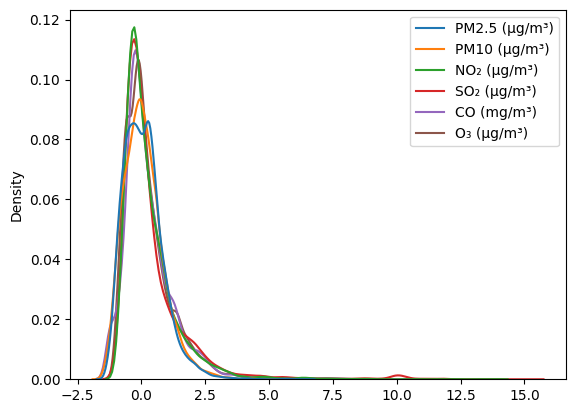

In [16]:
# Now the data is fully scaled
import seaborn as sns
sns.kdeplot(x_scaled[col]);

# DBSCAN Parameter Selection

Two key parameters:
- eps: neighborhood radius
- min_samples: minimum points to form a dense cluster

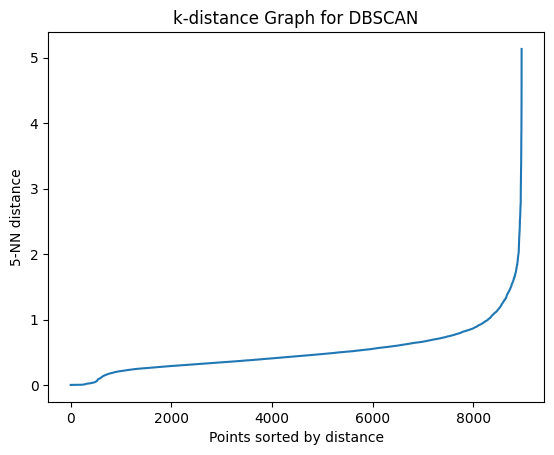

In [17]:
# eps is chosen using the k-distance elbow method.

from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt

neighbors = NearestNeighbors()
n_fit = neighbors.fit(x_scaled)
distances, indices = n_fit.kneighbors(x_scaled)

distances = distances[:, 4]
distances = sorted(distances)

plt.plot(distances)
plt.ylabel("5-NN distance")
plt.xlabel("Points sorted by distance")
plt.title("k-distance Graph for DBSCAN")
plt.show()

In [18]:
from sklearn.cluster import DBSCAN

In [19]:
for eps in [1.4, 1.5, 1.6, 1.7, 1.8]:
    db = DBSCAN(eps=eps, min_samples=7)
    labels = db.fit_predict(x_scaled)
    print(f"eps={eps}, anomalies={(labels == -1).sum()}")

eps=1.4, anomalies=193
eps=1.5, anomalies=136
eps=1.6, anomalies=101
eps=1.7, anomalies=83
eps=1.8, anomalies=68


In [20]:
#as alll the values of eps near the elbow point are showing similar kind of results, we can say that DBSCAN works best at eps=1.6
#min_samples is good when it is >= no. of features+1

In [21]:
dbscan = DBSCAN(eps=1.5, min_samples=7)
labels = dbscan.fit_predict(x_scaled)
df1['Cluster'] = labels
df1['Cluster'].value_counts()

Cluster
 0    8728
-1     136
 4      60
 3      19
 1       7
 2       7
 5       6
Name: count, dtype: int64

## DBSCAN Clustering and Anomaly Detection

DBSCAN clusters dense pollution patterns as normal behavior.
Points labeled as `-1` are treated as environmental anomalies.

In [22]:
anomalies=df1[df1['Cluster']==-1]
normal=df1[df1['Cluster']!=-1]

In [23]:
df1['Anomaly/Normal'] = df1['Cluster'].apply(
    lambda x: 'Anomaly' if x == -1 else 'Normal'
)

In [24]:
df1

,Station_Name,PM2.5 (µg/m³),PM10 (µg/m³),NO₂ (µg/m³),SO₂ (µg/m³),CO (mg/m³),O₃ (µg/m³),Cluster,Anomaly/Normal
Date,,,,,,,,,
2023-01-13,Chandkheda,68.43,114.36,6.47,6.30,0.59,21.67,0,Normal
2023-01-14,Chandkheda,58.08,102.45,6.84,6.10,0.69,21.28,0,Normal
2023-01-15,Chandkheda,52.41,93.06,6.93,4.98,0.66,21.53,0,Normal
2023-01-16,Chandkheda,70.02,117.51,8.15,5.89,0.98,20.74,0,Normal
2023-01-17,Chandkheda,61.45,104.97,8.51,6.61,0.90,20.42,0,Normal
...,...,...,...,...,...,...,...,...,...
2025-08-25,Sardar Vallabhai Patel Stadium,9.36,34.37,23.66,10.42,0.46,9.53,0,Normal
2025-08-26,Sardar Vallabhai Patel Stadium,15.41,52.38,27.04,10.74,0.81,13.18,0,Normal
2025-08-27,Sardar Vallabhai Patel Stadium,19.20,59.70,23.98,13.69,0.78,14.86,0,Normal


# Results & Visualizations

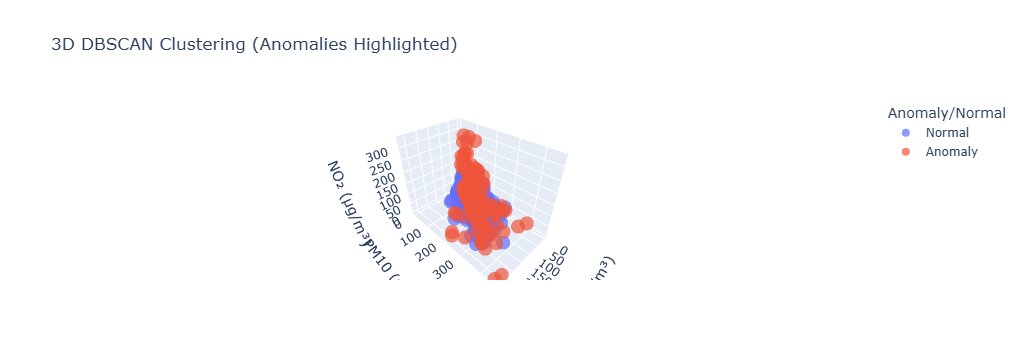

In [25]:
import plotly.express as px

fig = px.scatter_3d(
    df1,
    x='PM2.5 (µg/m³)',
    y='PM10 (µg/m³)',
    z='NO₂ (µg/m³)',
    color=df1['Anomaly/Normal'],
    title="3D DBSCAN Clustering (Anomalies Highlighted)",
    opacity=0.7
)

fig.show()

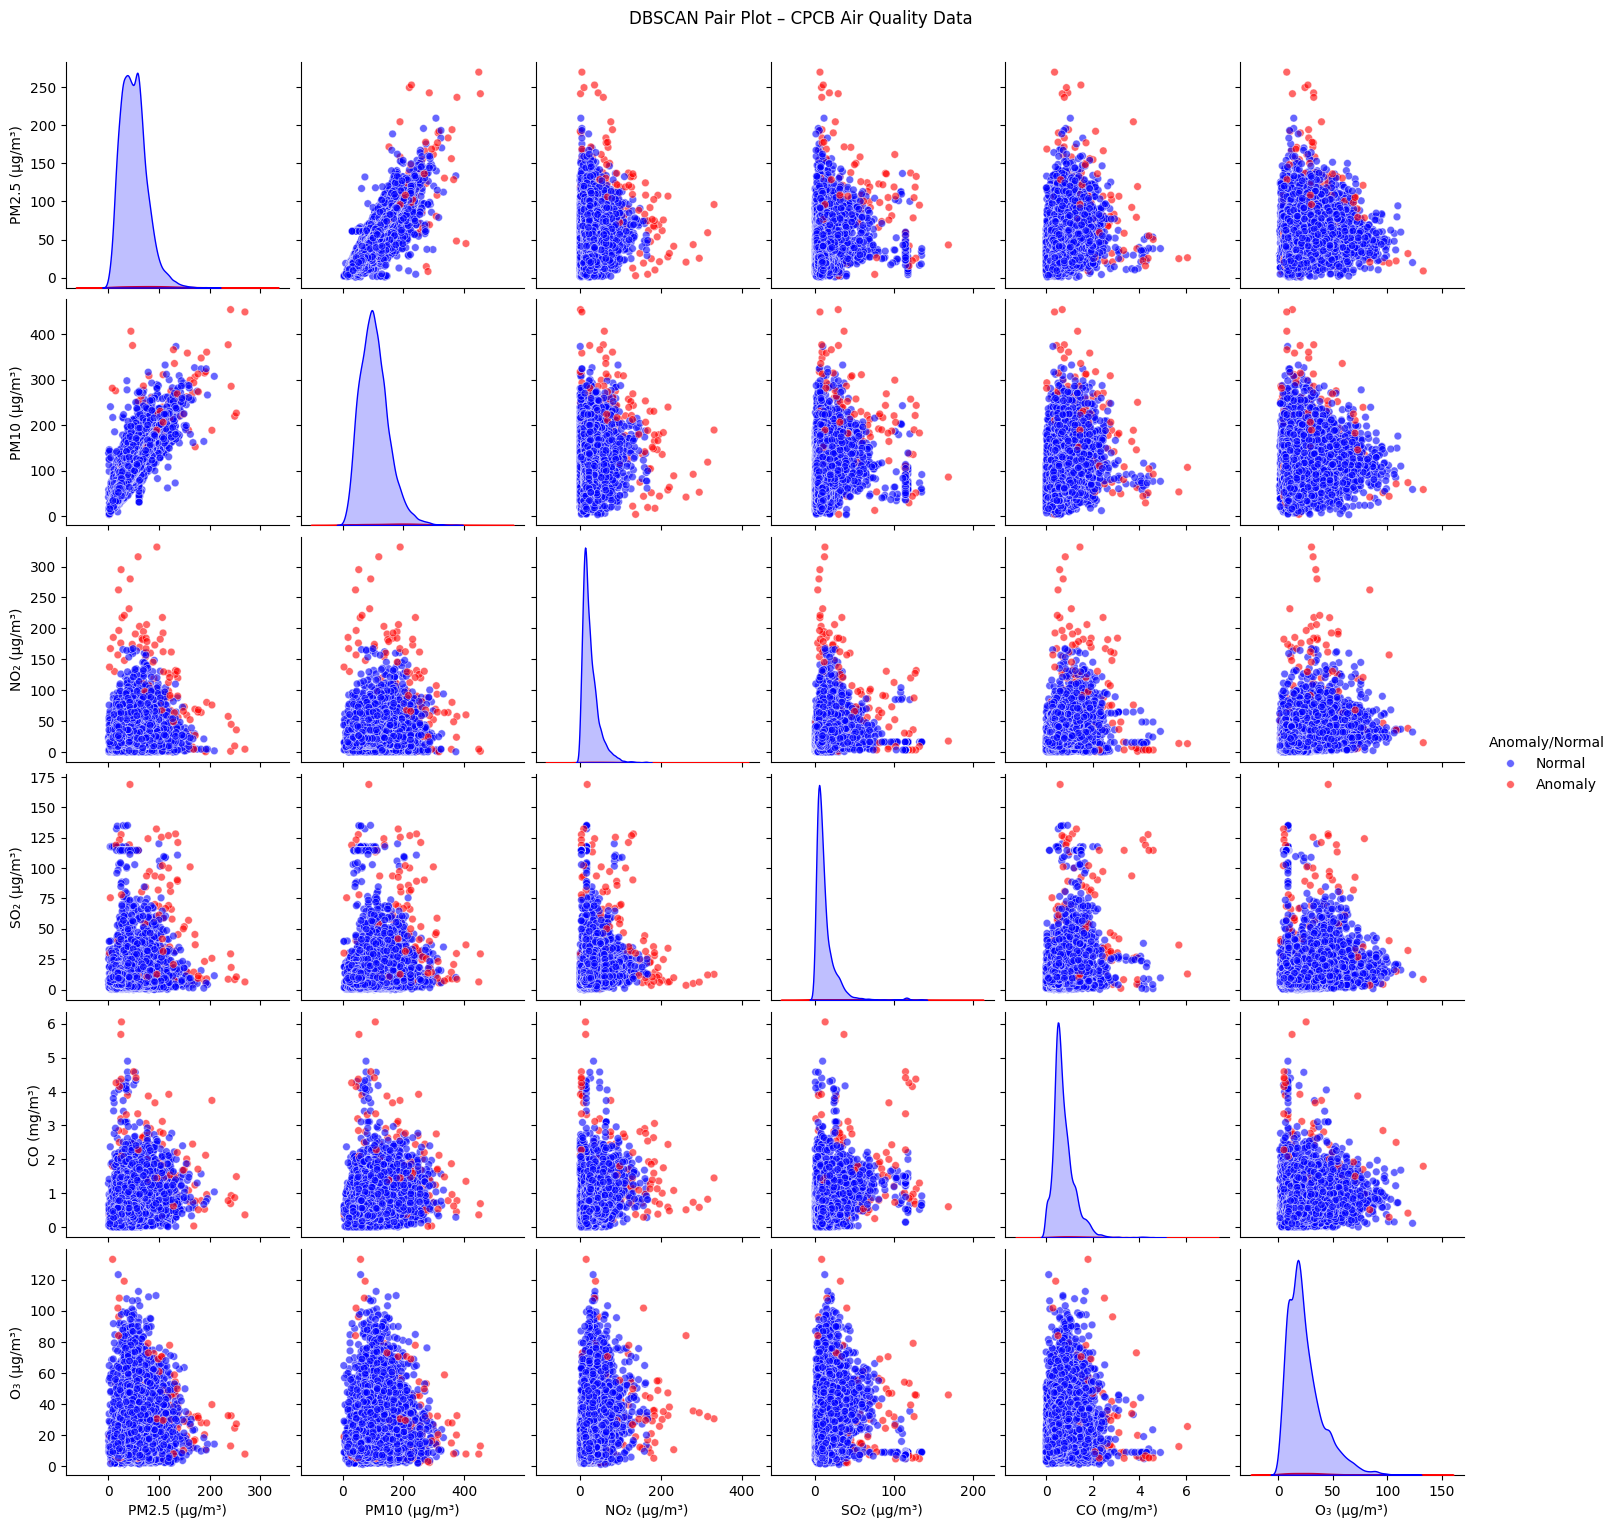

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(
    df1[col + ['Anomaly/Normal']],
    hue='Anomaly/Normal',
    palette={'Normal': 'blue', 'Anomaly': 'red'},
    diag_kind='kde',
    plot_kws={'alpha': 0.6, 's': 30}
)

plt.suptitle('DBSCAN Pair Plot – CPCB Air Quality Data', y=1.02)
plt.show()

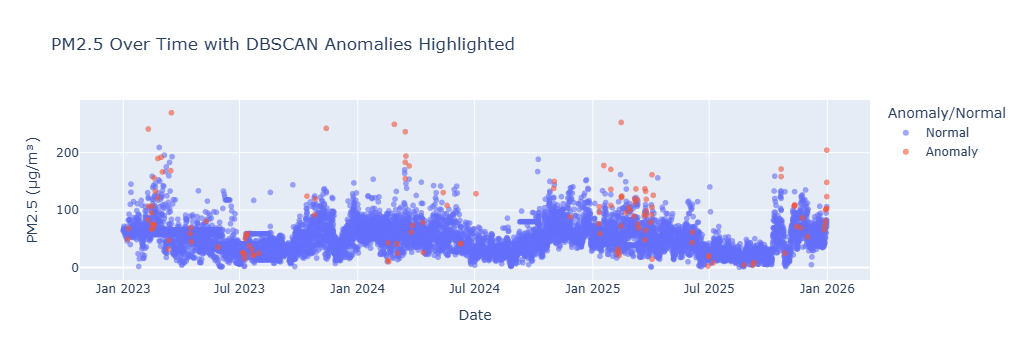

In [27]:
import plotly.express as px

fig = px.scatter(
    df1,
    x=df1.index,
    y="PM2.5 (µg/m³)",
    color=df1['Anomaly/Normal'].astype(str),
    title="PM2.5 Over Time with DBSCAN Anomalies Highlighted",
    opacity=0.6
)

fig.show()

In [28]:
import pandas as pd

# Station coordinate table (Ahmedabad)
station_coords = pd.DataFrame({
    "Station_Name": [
        "Chandkheda", "Gyaspur", "Maninagar", "Raikhad", "Rakhial",
        "SAC ISRO Bopal", "SAC ISRO Satellite",
        "SVPI Airport Hansol", "Sardar Vallabhai Patel Stadium"
    ],
    "Latitude": [
        23.11, 22.97, 23.00, 23.03, 23.02,
        23.03, 23.02,
        23.07, 23.04
    ],
    "Longitude": [
        72.58, 72.63, 72.60, 72.58, 72.61,
        72.47, 72.50,
        72.63, 72.57
    ]
})

station_coords

,Station_Name,Latitude,Longitude
0,Chandkheda,23.11,72.58
1,Gyaspur,22.97,72.63
2,Maninagar,23.00,72.60
3,Raikhad,23.03,72.58
4,Rakhial,23.02,72.61
5,SAC ISRO Bopal,23.03,72.47
6,SAC ISRO Satellite,23.02,72.50
7,SVPI Airport Hansol,23.07,72.63
8,Sardar Vallabhai Patel Stadium,23.04,72.57


In [29]:
num_anomalies = df1['Cluster'].value_counts().get(-1, 0)
total_points = len(df1)
percent_anomalies = (num_anomalies / total_points) * 100
print(f"Percentage of anomalies: {percent_anomalies:.2f}%")

Percentage of anomalies: 1.52%


In [30]:
anomalies = df1[df1['Cluster'] == -1]
anomalies['Station_Name'].value_counts()

Station_Name
Maninagar                         33
Gyaspur                           30
Rakhial                           21
Raikhad                           17
Chandkheda                        15
Sardar Vallabhai Patel Stadium    14
SVPI Airport Hansol                5
SAC ISRO Bopal                     1
Name: count, dtype: int64

In [31]:
df1.index[df1["Cluster"] == -1].month.value_counts()

Date
2     30
3     30
7     16
4     11
11    10
12    10
1     10
6      6
10     6
5      4
9      2
8      1
Name: count, dtype: int64

# Model Validation

In [32]:
from sklearn.metrics import silhouette_score #to evaluate clustering quality ranges from -1 to 1; higher is better

mask = df1['Cluster'] != -1
score = silhouette_score(x_scaled[mask], df1.loc[mask, 'Cluster'])
print("Silhouette score:", score)

Silhouette score: 0.532805060167671


In [33]:
from sklearn.metrics import davies_bouldin_score #to evaluate clustering performance (lower values indicate better clustering)

mask = df1['Cluster'] != -1
dbi = davies_bouldin_score(x_scaled[mask], df1.loc[mask, 'Cluster'])

print("Davies-Bouldin Index:", dbi)

Davies-Bouldin Index: 0.5495024789267365


In [34]:
from sklearn.metrics import calinski_harabasz_score #to measure cluster separation (higher values indicate better-defined and well-separated clusters)

mask = df1['Cluster'] != -1
chs = calinski_harabasz_score(x_scaled[mask], df1.loc[mask, 'Cluster'])

print("Calinski-Harabasz Score:", chs)

Calinski-Harabasz Score: 345.20955996932685


In [35]:
noise_ratio = (df1['Cluster'] == -1).mean()
print("Noise Ratio:", noise_ratio)

Noise Ratio: 0.015173491018632154


In [36]:
print("Stability check:")
for eps in [1.5, 1.6, 1.7]:
    labels = DBSCAN(eps=eps, min_samples=5).fit_predict(x_scaled)
    print(eps, (labels == -1).sum())

Stability check:
1.5 115
1.6 83
1.7 60


In [37]:
df1.groupby(['Station_Name', 'Cluster']).size().reset_index(name='Count')

,Station_Name,Cluster,Count
0,Chandkheda,-1,15
1,Chandkheda,0,1044
2,Chandkheda,3,2
3,Chandkheda,5,1
4,Gyaspur,-1,30
5,Gyaspur,0,817
6,Gyaspur,1,7
7,Maninagar,-1,33
8,Maninagar,0,1060
9,Raikhad,-1,17


In [38]:
anomalies[col].describe()

,PM2.5 (µg/m³),PM10 (µg/m³),NO₂ (µg/m³),SO₂ (µg/m³),CO (mg/m³),O₃ (µg/m³)
count,136.000000,136.000000,136.000000,136.000000,136.000000,136.000000
mean,92.296123,184.695437,89.506594,44.494853,1.619113,32.085824
std,59.174651,97.571858,75.997770,39.586721,1.183354,24.656726
min,2.660000,4.090000,0.620000,1.065000,0.020000,2.330000
25%,46.790000,108.322500,26.660000,11.047500,0.752500,12.625000
50%,84.971667,185.320000,68.880000,30.340000,1.325000,29.525000
75%,123.842500,250.365000,139.517500,68.785000,2.140000,42.560000
max,269.610000,453.480000,331.500000,168.820000,6.060000,133.170000


# Graphs

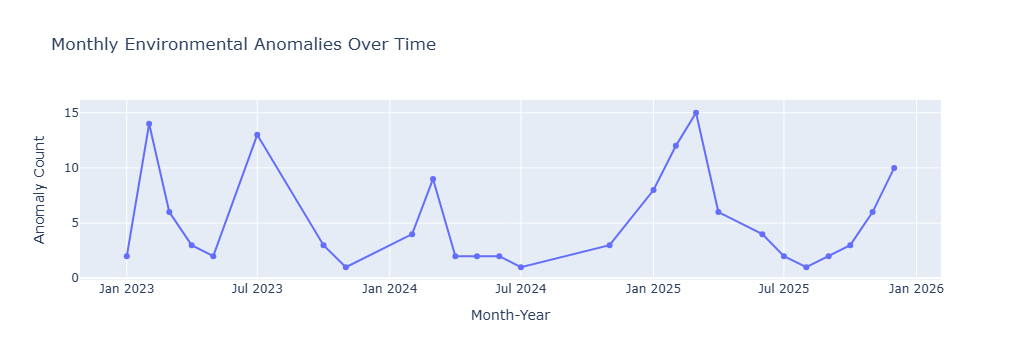

In [39]:
anomalies = df1[df1["Cluster"] == -1].reset_index()

anomaly_month_count = anomalies.groupby(anomalies["Date"].dt.to_period("M")).size().reset_index(name="Anomaly_Count")
anomaly_month_count["Date"] = anomaly_month_count["Date"].astype(str)

fig = px.line(
    anomaly_month_count,
    x="Date",
    y="Anomaly_Count",
    markers=True,
    title="Monthly Environmental Anomalies Over Time",
    labels={"Date": "Month-Year", "Anomaly_Count": "Anomaly Count"}
)

fig.show()

In [40]:
# as there are 6 features, we can't visualize it, so PCA is used to visualize in 2D and 3D

In [41]:
from sklearn.decomposition import PCA
import pandas as pd

# Reduce 6D → 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(x_scaled)

# Add PCA components into dataframe
df1["PC1"] = X_pca[:, 0]
df1["PC2"] = X_pca[:, 1]

print("Explained Variance Ratio:", pca.explained_variance_ratio_)
print("Total Variance Captured:", pca.explained_variance_ratio_.sum())

Explained Variance Ratio: [0.38434907 0.21762549]
Total Variance Captured: 0.6019745626850779


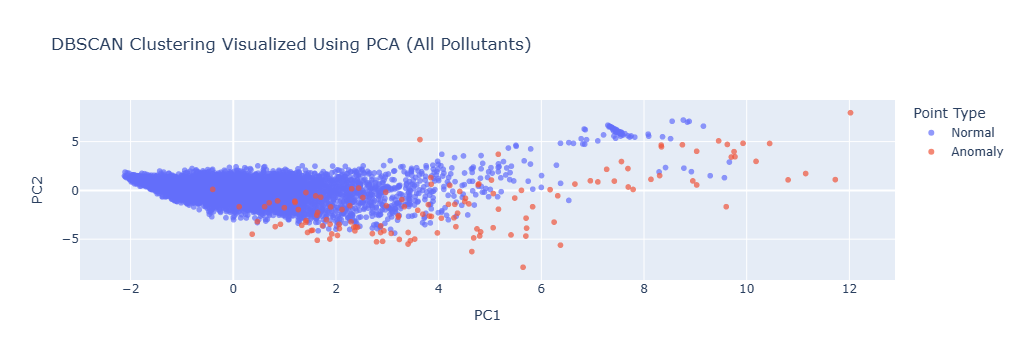

In [42]:
import plotly.express as px

fig = px.scatter(
    df1,
    x="PC1",
    y="PC2",
    color=df1["Cluster"].apply(lambda x: "Anomaly" if x == -1 else "Normal"),
    title="DBSCAN Clustering Visualized Using PCA (All Pollutants)",
    labels={"color": "Point Type"},
    opacity=0.7
)

fig.show()

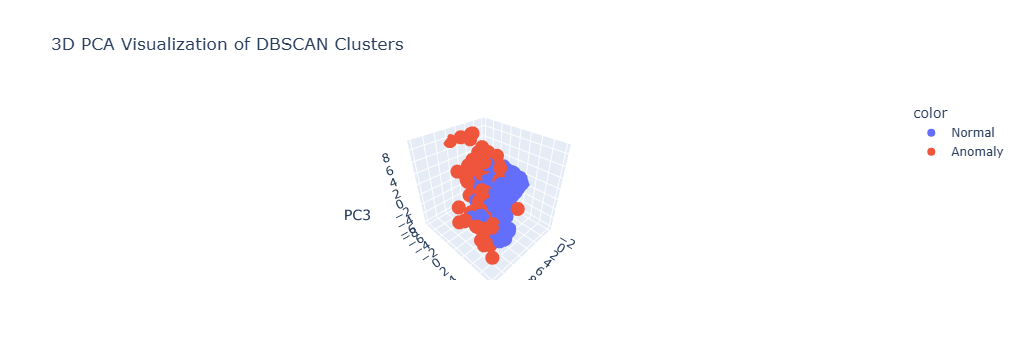

In [43]:
pca3 = PCA(n_components=3)
X_pca3 = pca3.fit_transform(x_scaled)

df1["PC3"] = X_pca3[:, 2]

fig = px.scatter_3d(
    df1,
    x="PC1",
    y="PC2",
    z="PC3",
    color=df1["Cluster"].apply(lambda x: "Anomaly" if x == -1 else "Normal"),
    title="3D PCA Visualization of DBSCAN Clusters"
)

fig.show()

In [44]:
import pandas as pd

# Take anomalies only
anomalies = df1[df1["Cluster"] == -1].reset_index()

# Extract Year and Month
anomalies["Year"] = anomalies["Date"].dt.year
anomalies["Month"] = anomalies["Date"].dt.month_name()

# Order months correctly
month_order = ["January", "February", "March", "April", "May", "June",
               "July", "August", "September", "October", "November", "December"]

anomalies["Month"] = pd.Categorical(anomalies["Month"], categories=month_order, ordered=True)

# Count anomalies per Year-Month
heatmap_data = anomalies.groupby(["Year", "Month"]).size().unstack(fill_value=0)

heatmap_data

Month,January,February,March,April,May,June,July,August,September,October,November,December
Year,,,,,,,,,,,,
2023,2,14,6,3,2,0,13,0,0,3,1,0
2024,0,4,9,2,2,2,1,0,0,0,3,0
2025,8,12,15,6,0,4,2,1,2,3,6,10


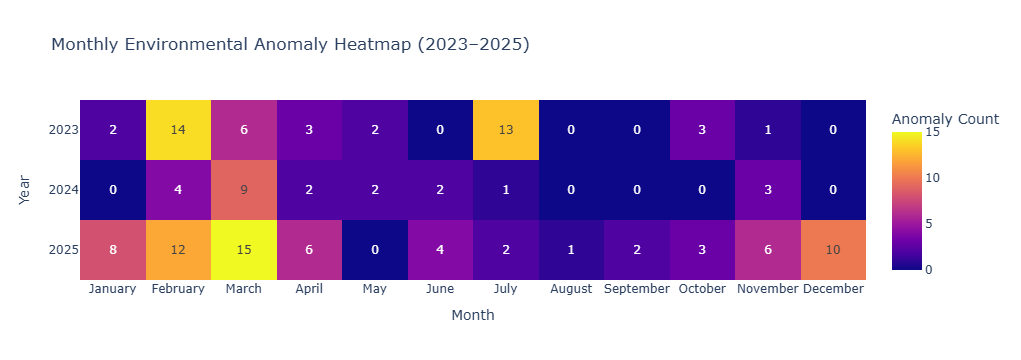

In [45]:
import plotly.express as px

fig = px.imshow(
    heatmap_data,
    text_auto=True,
    title="Monthly Environmental Anomaly Heatmap (2023–2025)",
    labels=dict(x="Month", y="Year", color="Anomaly Count"),
)

fig.show()

In [46]:
station_heatmap = anomalies.groupby(
    ["Station_Name", "Month"]
).size().unstack(fill_value=0)

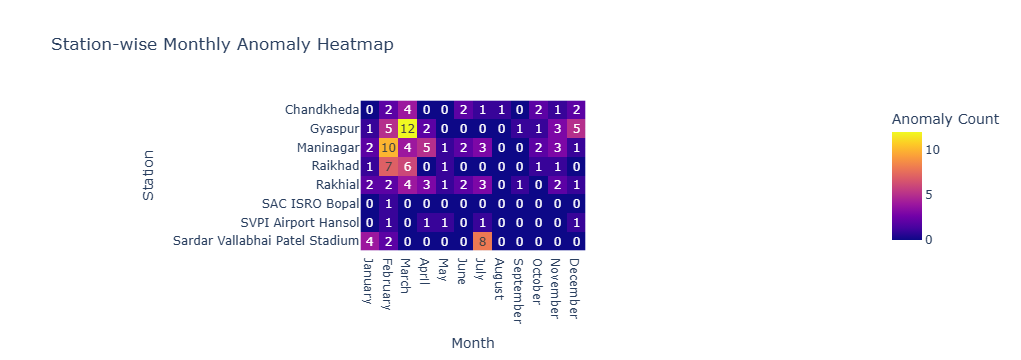

In [47]:
fig = px.imshow(
    station_heatmap,
    text_auto=True,
    title="Station-wise Monthly Anomaly Heatmap",
    labels=dict(x="Month", y="Station", color="Anomaly Count")
)

fig.show()

In [48]:
import pandas as pd

# Count anomalies per station
station_counts = anomalies.groupby("Station_Name").size().reset_index(name="Anomaly_Count")

station_counts

,Station_Name,Anomaly_Count
0,Chandkheda,15
1,Gyaspur,30
2,Maninagar,33
3,Raikhad,17
4,Rakhial,21
5,SAC ISRO Bopal,1
6,SVPI Airport Hansol,5
7,Sardar Vallabhai Patel Stadium,14


In [49]:
station_coords = pd.DataFrame({
    "Station_Name": [
        "Chandkheda", "Gyaspur", "Maninagar", "Raikhad", "Rakhial",
        "SAC ISRO Bopal", "SAC ISRO Satellite",
        "SVPI Airport Hansol", "Sardar Vallabhai Patel Stadium"
    ],
    "Latitude": [
        23.11, 22.97, 23.00, 23.03, 23.02,
        23.03, 23.02,
        23.07, 23.04
    ],
    "Longitude": [
        72.58, 72.63, 72.60, 72.58, 72.61,
        72.47, 72.50,
        72.63, 72.57
    ]
})
station_map = station_counts.merge(station_coords, on="Station_Name", how="left")

station_map

,Station_Name,Anomaly_Count,Latitude,Longitude
0,Chandkheda,15,23.11,72.58
1,Gyaspur,30,22.97,72.63
2,Maninagar,33,23.00,72.60
3,Raikhad,17,23.03,72.58
4,Rakhial,21,23.02,72.61
5,SAC ISRO Bopal,1,23.03,72.47
6,SVPI Airport Hansol,5,23.07,72.63
7,Sardar Vallabhai Patel Stadium,14,23.04,72.57


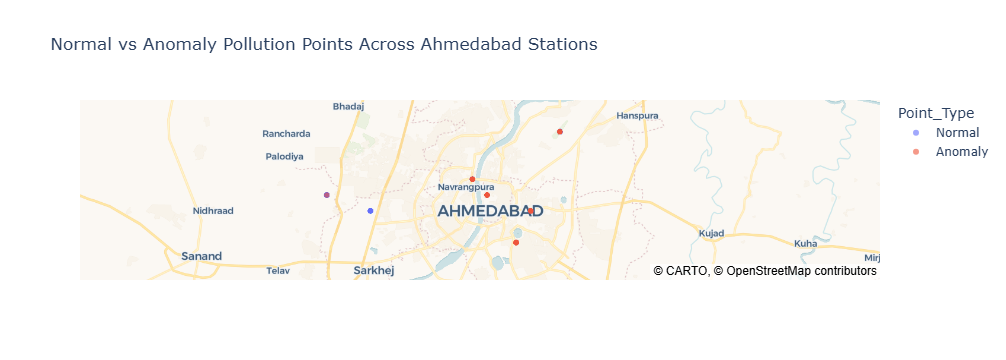

In [50]:
df_map = df1.merge(station_coords, on="Station_Name", how="left")

df_map["Point_Type"] = df_map["Cluster"].apply(
    lambda x: "Anomaly" if x == -1 else "Normal"
)

fig = px.scatter_map(
    df_map,
    lat="Latitude",
    lon="Longitude",
    color="Point_Type",
    hover_name="Station_Name",
    zoom=10,
    title="Normal vs Anomaly Pollution Points Across Ahmedabad Stations",
    opacity=0.6
)

fig.update_layout(mapbox_style="open-street-map")
fig.show()